In [17]:
from langgraph.graph import StateGraph, END, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
import os

from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages, count_tokens_approximately


In [27]:
model = ChatOpenAI(
    model="nvidia/nemotron-3-nano-30b-a3b:free",   # or any OpenRouter model
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [25]:
MAX_TOKENS = 100

In [20]:
def call_model(state: MessagesState):

    # Keep only the latest messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS,
    )

    print(
        "Current Token Count:",
        count_tokens_approximately(messages=messages)
    )

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {
        "messages": [response]
    }

In [21]:
builder = StateGraph(MessagesState)
builder.add_node('call_model', call_model)

builder.add_edge(START, 'call_model')


In [22]:
checkpoint = InMemorySaver()
graph = builder.compile(checkpointer=checkpoint)

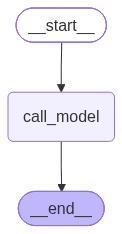

In [23]:
graph

In [ ]:
config = {'configurable':{'thread_id': 'thread_1'}}

result = graph.invoke({
    'messages':[{'role': 'user', 'content': 'Hello! I am kk'}]}, 
config,)

result['messages'][-1].content

Current Token Count: 24
Hello! I am kk
Hello! I am kk
Hello! I am kk


In [ ]:
config = {'configurable':{'thread_id': 'thread_1'}}

result = graph.invoke({
    'messages':[{'role': 'user', 'content': 'I am learning LangGraph'}]}, 
config,)
result['messages'][-1].content

Current Token Count: 89
Hello! I am kk
Hello! I am kk
Hello! I am kk
Hello! 😊 It looks like you're introducing yourself—thank you for saying hello! Could you tell me a bit more about yourself or what you'd like to talk about? I'm here to help with anything you need!
I am learning LangGraph


In [ ]:
config = {'configurable':{'thread_id': 'thread_1'}}

result = graph.invoke({
    'messages':[{'role': 'user', 'content': 'Can you explain me what is in-context learning and how it is important'}]}, 
config,)

result['messages'][-1].content

Current Token Count: 22
Can you explain me what is in-context learning and how it is important


In [31]:
result['messages'][-1].content

'## In‑Context Learning – What It Is\n\n**In‑context learning (ICL)** is a capability of large language models (LLMs) (and, more generally, of many recent foundation models) to **adapt to a new task or behavior by conditioning the model on a few examples placed in the prompt**, rather than by changing the model’s weights or running an explicit fine‑tuning step.\n\n| Term | Meaning |\n|------|---------|\n| **Context** | The text (or tokens) that appears **before** the actual generation request in the prompt. |\n| **In‑Context Learning** | The model uses the information in that context to infer the desired task and produce the appropriate output. |\n| **Few‑shot / Zero‑shot** | The “learning” can be *zero‑shot* (no demonstration examples) or *few‑shot* (a handful of input‑output pairs are shown). |\n\nIn short, the model **“learns” from the prompt itself**—the examples are part of the context it reads, and the model’s parameters stay fixed throughout inference.\n\n---\n\n## Why It Matter